# Sparse-Anomaly Global Null: One Alarm For Thousands of Streams

## Demonstrates the global-null e-process for "is anything wrong anywhere?":
- Sparse-mixture merging of K independent per-stream e-processes into one alarm
- Comparison with arithmetic-mean merging, which is valid under arbitrary dependence
- Localisation: posterior over sparsity, participation ratio, top streams
- Identifying *which* streams are anomalous with e-BH (FDR control)
- Replicated comparisons: detection rate and alarm time over many independent worlds
- When the arithmetic mean wins: a single badly failed stream
- The Donoho-Jin detection boundary and the detection moment
- Type-I error validity under the global null
- Real-world: neuroimaging voxel activation (K = 20,000)
- Real-world: MLOps feature-drift monitoring after a deploy (K = 2,000)
- Real-world: supply-chain SKU demand anomalies (K = 1,500)
- Real-world: LLM prompt-cluster quality regression (K = 5,000)
- Real-world: clinical safety surveillance across hospital units (K = 3,000)

Monitoring thousands of streams poses two different questions. *Which streams are off?*
is multiple testing, answered by `e_bh` or `e_bonferroni` in the parallel engine. *Is
anything off at all?* is the **global null**, and it is the question an on-call
engineer, a safety board or a compliance officer asks first.

**How the simulations are set up.** Nothing about the anomalies is handed to the test.
Each stream is independently anomalous with an unknown probability, so the *number* of
anomalies is random rather than chosen; effect sizes are drawn from a distribution whose
mean and spread come from the domain, not from what makes a method look good; and where
a change point makes sense, its time is drawn too. Because a single run is one draw from
that world, every comparison below is repeated over many independent worlds and reported
as a rate. Some runs detect nothing at all - that is the honest behaviour of a monitor
near its detection limit, not a bug.

Per-stream evidence comes from the Rust parallel engine; the merge is the Python
`SparseMixtureMerger`. The merge consumes the *current values* of the K per-stream test
supermartingales and returns a global e-process value - it must not be accumulated over
time a second time.

References:
    Perez-Ortiz, Castro & Stoepker (2025). Sequential anomaly detection in a
    high-dimensional setting. arXiv:2506.22588.
    - Eq. (4): per-stream test supermartingale;  Eq. (6): the sparse mixture
    - Eq. (9): the exponential sparsity grid;  Thms. 2.1-2.7: validity and detection
    Donoho & Jin (2004). Higher criticism for detecting sparse heterogeneous mixtures.
    Annals of Statistics 32(3), Section 1.1: the detection boundary rho(beta).
    Vovk & Wang (2024). Merging e-values. Annals of Statistics, Eq. (4): every
    martingale merging function is a gambling system.
    Wang, Dandapanthula & Ramdas (2025). Sharp bounds for multiple models in e-value
    combination - why the product-like merges need independence.
    Ramdas & Wang (2025). Hypothesis testing with e-values, Ch. 4 (e-BH), Ch. 8.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig
from expectation.modules.merging import (
    ArithmeticMeanMerger,
    SparseMixtureMerger,
    detection_boundary,
    sparsity_grid,
)

ALPHA = 0.05
LOG_THRESHOLD = np.log(1 / ALPHA)     # Ville's rejection line, in log capital

# 1. The World We Are Monitoring

Test H0: every one of the K streams is null vs H1: at least one is not.

Reality is simulated the way the anomaly actually arises, following the model of
Perez-Ortiz, Castro & Stoepker (2025): each stream is independently anomalous with
probability `anomaly_rate`, and an anomalous stream's observations are shifted by an
effect drawn from a distribution. Three consequences matter for reading the rest of the
notebook:

- the **number** of anomalous streams is a random variable, not a setting;
- the **effect sizes differ between streams**, so some anomalies are large enough to
  find and others sit below the noise floor at this horizon;
- the test sees only the standardised observations. It is told K and alpha, nothing
  about which streams are involved, how many there are, or how large the shifts are.

Each stream gets its own e-process from the parallel engine, and at every time step the
current per-stream values go to two merging functions:

- `SparseMixtureMerger` computes
  F(e) = sum_j pi_j prod_k (1 - eps_j + eps_j e_k) over the sparsity grid of Eq. (9).
  It multiplies evidence across the anomalous streams.
- `ArithmeticMeanMerger` averages the K e-values. It is valid under *arbitrary*
  dependence between streams, which is a genuinely strong property, but averaging a few
  informative values with thousands of uninformative ones divides the evidence by K.

In [2]:
K, horizon = 4000, 120
anomaly_rate = 0.002                  # unknown to the test: about 1 stream in 500
effect_mean, effect_sd = 0.5, 0.12    # anomalous streams shift by roughly half a sigma

rng = np.random.default_rng(11)

is_anomalous = rng.random(K) < anomaly_rate            # the count is random, not chosen
n_anomalous = int(is_anomalous.sum())
effect = np.zeros(K)
effect[is_anomalous] = np.clip(rng.normal(effect_mean, effect_sd, n_anomalous), 0.05, None)

engine = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater", combiner="all_in"),
    null_values=0.0,
    variance=1.0,            # known unit variance: the mixture martingale applies per stream
)
sparse = SparseMixtureMerger(K)
mean = ArithmeticMeanMerger(K)

print(f"sparsity grid: {len(sparse.epsilons)} values of eps from "
      f"{sparse.epsilons[0]:.5f} (1 stream in {1 / sparse.epsilons[0]:.0f}) to "
      f"{sparse.epsilons[-1]:.5f} (1 in {1 / sparse.epsilons[-1]:.0f})")

log_sparse, log_mean = [], []
alarm_sparse = alarm_mean = None

for t in range(1, horizon + 1):
    engine.step(rng.standard_normal(K) + effect)
    log_e = engine.log_e_processes()

    log_sparse.append(sparse.merge_log(log_e).log_merged_e_value)
    log_mean.append(mean.merge(np.exp(log_e)).log_merged_e_value)

    if alarm_sparse is None and max(log_sparse) >= LOG_THRESHOLD:
        alarm_sparse = t
    if alarm_mean is None and max(log_mean) >= LOG_THRESHOLD:
        alarm_mean = t

print(f"\nwhat the monitor reported over {horizon} steps")
print(f"  sparse mixture : alarm at t = {alarm_sparse}, max log e-process {max(log_sparse):.1f}")
print(f"  arithmetic mean: alarm at t = {alarm_mean}, max log e-process {max(log_mean):.1f}")

print(f"\nwhat Reality actually did (revealed only now, for evaluation)")
print(f"  anomalous streams drawn        : {n_anomalous} of {K}")
print(f"  their effect sizes             : "
      f"{np.round(np.sort(effect[is_anomalous])[::-1], 2)}")
print(f"  strongest single-stream z at T : {effect.max() * np.sqrt(horizon):.1f}")

sparsity grid: 32 values of eps from 0.00025 (1 stream in 4000) to 0.01489 (1 in 67)

what the monitor reported over 120 steps
  sparse mixture : alarm at t = 68, max log e-process 34.6
  arithmetic mean: alarm at t = 69, max log e-process 11.7

what Reality actually did (revealed only now, for evaluation)
  anomalous streams drawn        : 5 of 4000
  their effect sizes             : [0.62 0.57 0.55 0.49 0.49]
  strongest single-stream z at T : 6.8


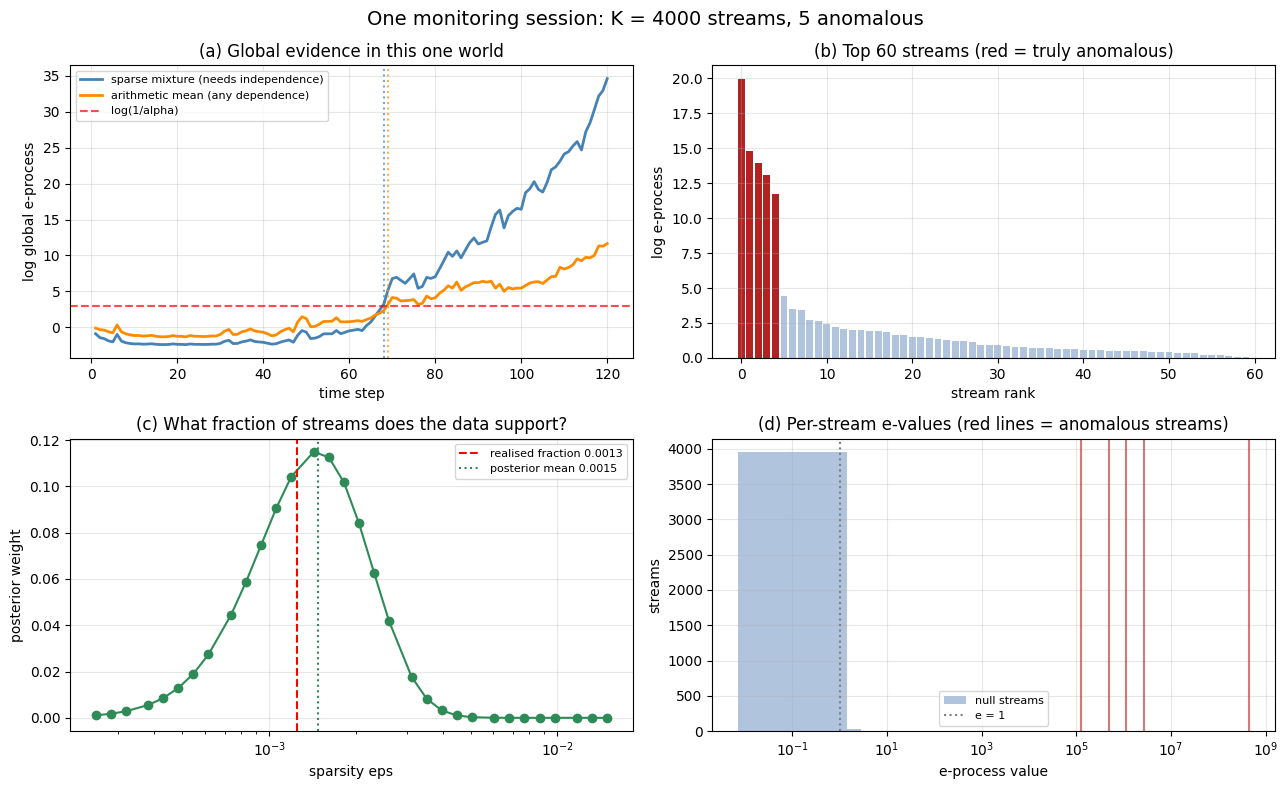

In [3]:
log_e_final = engine.log_e_processes()
diagnostics = sparse.diagnostics(np.exp(log_e_final))
truth = set(np.flatnonzero(is_anomalous).tolist())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax.plot(range(1, horizon + 1), log_sparse, lw=2, color='steelblue',
        label='sparse mixture (needs independence)')
ax.plot(range(1, horizon + 1), log_mean, lw=2, color='darkorange',
        label='arithmetic mean (any dependence)')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
if alarm_sparse:
    ax.axvline(alarm_sparse, color='steelblue', ls=':', alpha=0.7)
if alarm_mean:
    ax.axvline(alarm_mean, color='darkorange', ls=':', alpha=0.7)
ax.set_xlabel('time step'); ax.set_ylabel('log global e-process')
ax.set_title('(a) Global evidence in this one world')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
order = np.argsort(log_e_final)[::-1][:60]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(60), log_e_final[order], color=colours)
ax.set_xlabel('stream rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 60 streams (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(sparse.epsilons, diagnostics.posterior_sparsity, 'o-', color='seagreen')
ax.axvline(n_anomalous / K, color='red', ls='--',
           label=f'realised fraction {n_anomalous / K:.4f}')
ax.axvline(diagnostics.sparsity_posterior_mean, color='seagreen', ls=':',
           label=f'posterior mean {diagnostics.sparsity_posterior_mean:.4f}')
ax.set_xscale('log'); ax.set_xlabel('sparsity eps'); ax.set_ylabel('posterior weight')
ax.set_title('(c) What fraction of streams does the data support?')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(np.exp(log_e_final[~is_anomalous]), bins=60, color='lightsteelblue',
        label='null streams')
ax.axvline(1.0, color='grey', ls=':', label='e = 1')
for i in np.flatnonzero(is_anomalous):
    ax.axvline(np.exp(log_e_final[i]), color='firebrick', alpha=0.6)
ax.set_xscale('log'); ax.set_xlabel('e-process value'); ax.set_ylabel('streams')
ax.set_title('(d) Per-stream e-values (red lines = anomalous streams)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'One monitoring session: K = {K} streams, {n_anomalous} anomalous', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Localisation: Where Is the Evidence Coming From?

A single global alarm is not actionable on its own. The merge carries three by-products
that turn it into a triage list, at no extra cost:

- **posterior over sparsity** - what anomaly fraction the data support, which estimates
  *how many* streams are involved before any per-stream test is run;
- **participation ratio** - the effective number of streams carrying the evidence. A
  stream sitting at e = 1 contributes exactly zero;
- **top streams** - the ranking by e-value, the same for every eps on the grid, so the
  shortlist does not depend on the sparsity assumption.

Compare these to the realised truth. The posterior-mean count estimates the number of
anomalies the data can *see*, so it tracks the detectable subset rather than the total
drawn - streams whose effect fell near zero are invisible by construction.

In [4]:
diagnostics = sparse.diagnostics(np.exp(engine.log_e_processes()))

print(f"realised number of anomalous streams : {n_anomalous}")
print(f"posterior-mean sparsity eps          : {diagnostics.sparsity_posterior_mean:.5f}")
print(f"  implied number of streams          : {diagnostics.sparsity_posterior_mean * K:.1f}")
print(f"participation ratio                  : {diagnostics.participation_ratio:.2f} "
      f"effective streams")
print()

top = diagnostics.top_streams
print(f"top {len(top)} streams by e-value:")
for rank, stream in enumerate(top, start=1):
    if stream in truth:
        flag = f"anomalous (effect {effect[stream]:.2f})"
    else:
        flag = "null"
    print(f"  {rank:2d}. stream {stream:5d}   log e = {log_e_final[stream]:6.2f}   {flag}")
print(f"\ntrue positives in the shortlist: {len(set(top) & truth)} "
      f"of {min(len(top), n_anomalous)} findable")

realised number of anomalous streams : 5
posterior-mean sparsity eps          : 0.00147
  implied number of streams          : 5.9
participation ratio                  : 4.55 effective streams

top 10 streams by e-value:
   1. stream  1084   log e =  19.94   anomalous (effect 0.62)
   2. stream  3833   log e =  14.80   anomalous (effect 0.49)
   3. stream  1600   log e =  13.94   anomalous (effect 0.49)
   4. stream  2791   log e =  13.11   anomalous (effect 0.55)
   5. stream  1069   log e =  11.73   anomalous (effect 0.57)
   6. stream  1259   log e =   4.42   null
   7. stream   697   log e =   3.50   null
   8. stream  1321   log e =   3.45   null
   9. stream  3766   log e =   2.72   null
  10. stream  3367   log e =   2.62   null

true positives in the shortlist: 5 of 5 findable


# 3. Identifying Which Streams Are Anomalous: e-BH

The global alarm says *something* is wrong. e-BH says *which*, with false discovery rate
control at level alpha (Ramdas & Wang 2025, Section 4.2, Thm. 4.2). The two are
complementary: the global test fires earlier and on weaker evidence, the per-stream
procedure gives the list to act on but requires each stream to clear its own bar.

Note the warning attached to `e_bh` in the engine: it is not *carefree*, so rejections
can disappear as more data arrive. Use `adjusted_e_bh()` when a stable, monotone
rejection set matters (a regulator's list, an audit trail).

In [5]:
bh = engine.e_bh()
bonferroni = engine.e_bonferroni()

found = set(np.flatnonzero(bh.rejected).tolist())
found_fwer = set(np.flatnonzero(bonferroni.rejected).tolist())

print(f"global null rejected by the sparse mixture at t = {alarm_sparse}")
print(f"streams actually anomalous              : {n_anomalous}")
print()
print(f"e-BH (FDR {ALPHA})        : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")
print(f"e-Bonferroni (FWER {ALPHA}): {bonferroni.n_rejected} flagged, "
      f"{len(found_fwer & truth)} true, {len(found_fwer - truth)} false")
print()
print("Any stream that goes unflagged is one whose effect was too small to clear a")
print("per-stream bar at this horizon. Its evidence still contributes to the global")
print("alarm, which is the point of merging.")

global null rejected by the sparse mixture at t = 68
streams actually anomalous              : 5

e-BH (FDR 0.05)        : 5 flagged, 5 true, 0 false
e-Bonferroni (FWER 0.05): 5 flagged, 5 true, 0 false

Any stream that goes unflagged is one whose effect was too small to clear a
per-stream bar at this horizon. Its evidence still contributes to the global
alarm, which is the point of merging.


# 4. How Often Does Each Merge Actually Fire?

The previous sections are a single draw from the world defined in section 1, and a
single draw proves nothing: the number of anomalies and their sizes are random, so
another week of monitoring gives a different answer. The question a practitioner needs
answered is the operating characteristic - *how often* does each merge fire, and *when*.

We replay the same world 50 times with independent randomness and report detection
rates, median alarm times and median evidence. This is the honest comparison between the
two merging functions, and it is what should drive the choice between them.

**Read the result carefully, because it is not the one the marketing would suggest.**
Both merges detect in nearly every world, and on *alarm time* they are neck and neck -
the arithmetic mean is often marginally earlier. Crossing log(1/alpha) takes only three
nats, and the mean reaches three nats about as fast as the mixture does. Where they
differ enormously is in evidence accumulated afterwards, which is what makes the alarm
defensible under scrutiny and what drives the localisation diagnostics in section 2.
Choose the sparse mixture for the strength and interpretability of the evidence, not for
a faster page.

50 independent worlds, K = 4000, horizon 120
  anomalous streams drawn : median 8, range 2-16

  sparse mixture  detected 48/50 worlds, median alarm t = 46, median log evidence 52.6
  arithmetic mean detected 48/50 worlds, median alarm t = 44, median log evidence 18.1

  where both fired (48 worlds): sparse earlier in 13, later in 25, tied in 10
  median log-evidence advantage of the sparse mixture: 33.0 nats


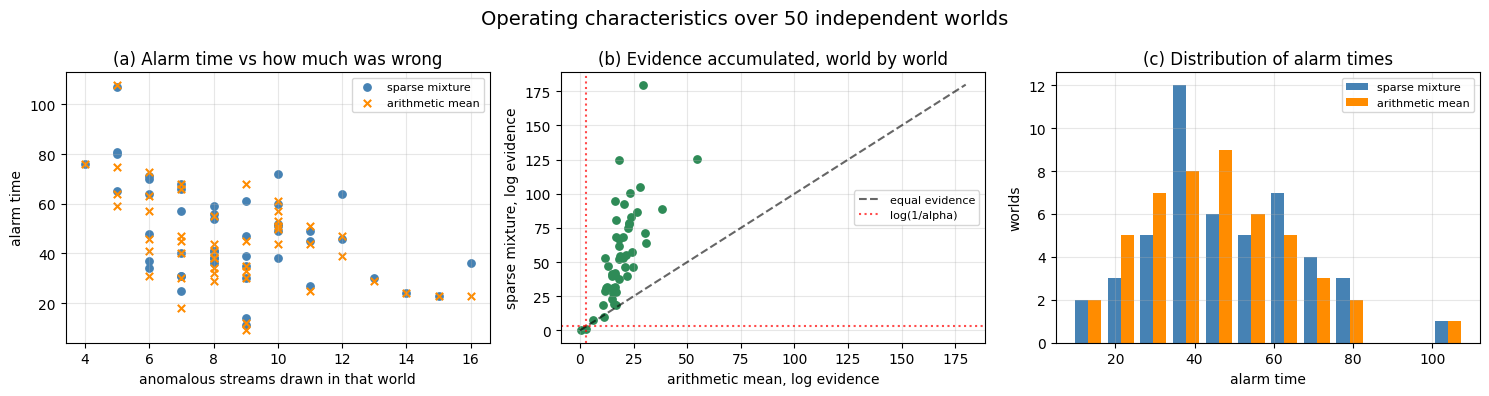

In [6]:
n_worlds = 50
records = []

for world in range(n_worlds):
    rng_w = np.random.default_rng(2000 + world)

    anomalous_w = rng_w.random(K) < anomaly_rate
    m_w = int(anomalous_w.sum())
    effect_w = np.zeros(K)
    effect_w[anomalous_w] = np.clip(rng_w.normal(effect_mean, effect_sd, m_w), 0.05, None)

    eng_w = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse_w, mean_w = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    max_sparse = max_mean = 0.0
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng_w.step(rng_w.standard_normal(K) + effect_w)
        log_e_w = eng_w.log_e_processes()
        max_sparse = max(max_sparse, sparse_w.merge_log(log_e_w).log_merged_e_value)
        max_mean = max(max_mean, mean_w.merge(np.exp(log_e_w)).log_merged_e_value)
        if alarm_s is None and max_sparse >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max_mean >= LOG_THRESHOLD:
            alarm_m = t

    records.append({"world": world, "n_anomalous": m_w,
                    "alarm_sparse": alarm_s, "alarm_mean": alarm_m,
                    "log_sparse": max_sparse, "log_mean": max_mean})

replications = pd.DataFrame(records)
detected_s = replications['alarm_sparse'].notna()
detected_m = replications['alarm_mean'].notna()
both = detected_s & detected_m

print(f"{n_worlds} independent worlds, K = {K}, horizon {horizon}")
print(f"  anomalous streams drawn : median {replications['n_anomalous'].median():.0f}, "
      f"range {replications['n_anomalous'].min()}-{replications['n_anomalous'].max()}")
print()
print(f"  sparse mixture  detected {detected_s.sum():2d}/{n_worlds} worlds, "
      f"median alarm t = {replications.loc[detected_s, 'alarm_sparse'].median():.0f}, "
      f"median log evidence {replications['log_sparse'].median():.1f}")
print(f"  arithmetic mean detected {detected_m.sum():2d}/{n_worlds} worlds, "
      f"median alarm t = {replications.loc[detected_m, 'alarm_mean'].median():.0f}, "
      f"median log evidence {replications['log_mean'].median():.1f}")
print()
print(f"  where both fired ({both.sum()} worlds): sparse earlier in "
      f"{(replications.loc[both, 'alarm_sparse'] < replications.loc[both, 'alarm_mean']).sum()}, "
      f"later in "
      f"{(replications.loc[both, 'alarm_sparse'] > replications.loc[both, 'alarm_mean']).sum()}, "
      f"tied in "
      f"{(replications.loc[both, 'alarm_sparse'] == replications.loc[both, 'alarm_mean']).sum()}")
print(f"  median log-evidence advantage of the sparse mixture: "
      f"{(replications['log_sparse'] - replications['log_mean']).median():.1f} nats")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(replications['n_anomalous'], replications['alarm_sparse'], s=28,
           color='steelblue', label='sparse mixture')
ax.scatter(replications['n_anomalous'], replications['alarm_mean'], s=28,
           color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous streams drawn in that world'); ax.set_ylabel('alarm time')
ax.set_title('(a) Alarm time vs how much was wrong')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(replications['log_mean'], replications['log_sparse'], s=28, color='seagreen')
limit = max(replications['log_sparse'].max(), replications['log_mean'].max())
ax.plot([0, limit], [0, limit], 'k--', alpha=0.6, label='equal evidence')
ax.axhline(LOG_THRESHOLD, color='red', ls=':', alpha=0.7, label='log(1/alpha)')
ax.axvline(LOG_THRESHOLD, color='red', ls=':', alpha=0.7)
ax.set_xlabel('arithmetic mean, log evidence'); ax.set_ylabel('sparse mixture, log evidence')
ax.set_title('(b) Evidence accumulated, world by world')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.hist([replications.loc[detected_s, 'alarm_sparse'].to_numpy(dtype=float),
         replications.loc[detected_m, 'alarm_mean'].to_numpy(dtype=float)],
        bins=12, color=['steelblue', 'darkorange'],
        label=['sparse mixture', 'arithmetic mean'])
ax.set_xlabel('alarm time'); ax.set_ylabel('worlds')
ax.set_title('(c) Distribution of alarm times')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'Operating characteristics over {n_worlds} independent worlds', fontsize=14)
plt.tight_layout()
plt.show()

# 5. When the Arithmetic Mean Wins: a Single Failed Stream

The sparse mixture is not uniformly better. Its prior spreads weight across a grid of
sparsity levels, which costs a little when the truth sits at the very edge of that grid.

The extreme case is one stream and one stream only - a failed sensor reading high, a
single merchant committing fraud, one host with a bad disk. Then the arithmetic mean is
essentially max_k e_k / K, which is the Bonferroni-optimal thing to do, and the mixture
pays for hedging over sparsity levels it does not need.

We simulate exactly that: one stream out of K fails, with a magnitude drawn from a
distribution appropriate to hardware failure - large, but not known in advance - and
replicate to see how often each merge wins.

In [7]:
n_worlds_loud, horizon_loud = 30, 60
loud_records = []

for world in range(n_worlds_loud):
    rng_l = np.random.default_rng(7000 + world)

    failed = int(rng_l.integers(0, K))                        # which stream fails is unknown
    magnitude = float(np.clip(rng_l.normal(1.5, 0.4), 0.2, None))   # a failed sensor reads badly
    effect_l = np.zeros(K)
    effect_l[failed] = magnitude

    eng_l = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse_l, mean_l = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    max_s = max_m = 0.0
    alarm_s = alarm_m = None
    for t in range(1, horizon_loud + 1):
        eng_l.step(rng_l.standard_normal(K) + effect_l)
        log_e_l = eng_l.log_e_processes()
        max_s = max(max_s, sparse_l.merge_log(log_e_l).log_merged_e_value)
        max_m = max(max_m, mean_l.merge(np.exp(log_e_l)).log_merged_e_value)
        if alarm_s is None and max_s >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max_m >= LOG_THRESHOLD:
            alarm_m = t

    loud_records.append({"magnitude": magnitude, "alarm_sparse": alarm_s,
                         "alarm_mean": alarm_m, "log_sparse": max_s, "log_mean": max_m})

loud = pd.DataFrame(loud_records)
both_loud = loud['alarm_sparse'].notna() & loud['alarm_mean'].notna()

print(f"{n_worlds_loud} worlds, exactly one failed stream among {K}")
print(f"  failure magnitude       : median {loud['magnitude'].median():.2f} sigma")
print(f"  sparse mixture alarmed  : {loud['alarm_sparse'].notna().sum()}/{n_worlds_loud}, "
      f"median alarm t = {loud['alarm_sparse'].median():.0f}")
print(f"  arithmetic mean alarmed : {loud['alarm_mean'].notna().sum()}/{n_worlds_loud}, "
      f"median alarm t = {loud['alarm_mean'].median():.0f}")
print(f"  mean strictly earlier in "
      f"{(loud.loc[both_loud, 'alarm_mean'] < loud.loc[both_loud, 'alarm_sparse']).sum()} "
      f"of {both_loud.sum()} worlds")
print(f"  median log-evidence advantage of the mean: "
      f"{(loud['log_mean'] - loud['log_sparse']).median():.1f} nats")
print()
print("Rule of thumb: the sparse mixture wins when several streams each carry real")
print("evidence; the mean wins when exactly one does - and the mean is the only valid")
print("option when the streams are dependent.")

30 worlds, exactly one failed stream among 4000
  failure magnitude       : median 1.65 sigma
  sparse mixture alarmed  : 29/30, median alarm t = 11
  arithmetic mean alarmed : 30/30, median alarm t = 10
  mean strictly earlier in 18 of 29 worlds
  median log-evidence advantage of the mean: 2.1 nats

Rule of thumb: the sparse mixture wins when several streams each carry real
evidence; the mean wins when exactly one does - and the mean is the only valid
option when the streams are dependent.


# 6. The Detection Boundary and the Detection Moment

Sparse detection has a hard limit that no method can beat. With K streams, anomaly
fraction eps = K^(-beta) and per-step signal delta = sqrt(2 ln K / T*), the Donoho-Jin
boundary says detection is impossible before

    t* = T* rho(beta),    rho(beta) = beta - 1/2 on (1/2, 3/4],  (1 - sqrt(1-beta))^2 on [3/4, 1]

and possible after (Donoho & Jin 2004, Section 1.1; Perez-Ortiz, Castro & Stoepker 2025,
Eq. (3) and Thms. 2.5-2.7). Sparser signals need strictly more time, and this is a
physical limit rather than a tuning artefact.

This is the one section where the anomaly rate is set deliberately: the boundary is a
statement *about* eps = K^(-beta), so sweeping beta is the experiment. The indicators are
still drawn as independent Bernoulli(eps), so the realised counts vary.

**An honest qualification.** The theory's detection moment is stated for the *oracle*
likelihood-ratio martingale of their Eq. (4), which knows delta. The engine's mixture
martingale does not, and pays the usual logarithmic price for mixing over effect sizes.
The empirical alarm times therefore sit well above t*, but they track its **shape**.

K = 4000, T* = 40, per-step signal delta = 0.644
  beta  E[anomalies]  t* (oracle)   median alarm
  0.55          41.8          2.0           13.5


  0.65          18.2          6.0           27.0


  0.75           8.0         10.0           34.5


  0.85           3.5         15.0           45.5


  0.95           1.5         24.1           78.5


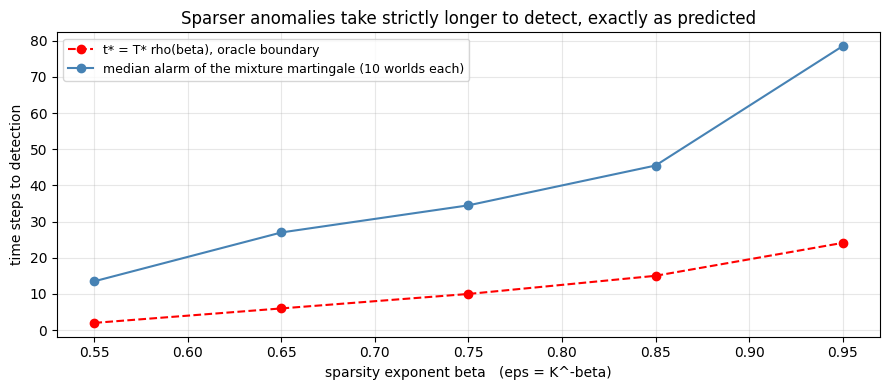

In [8]:
K_boundary, T_star = 4000, 40.0
delta = np.sqrt(2 * np.log(K_boundary) / T_star)
betas = np.array([0.55, 0.65, 0.75, 0.85, 0.95])
n_reps = 10

print(f"K = {K_boundary}, T* = {T_star:.0f}, per-step signal delta = {delta:.3f}")
print(f"{'beta':>6} {'E[anomalies]':>13} {'t* (oracle)':>12} {'median alarm':>14}")

predicted, empirical = [], []
for beta in betas:
    eps = K_boundary ** -beta
    t_star = T_star * detection_boundary(beta)

    alarms = []
    for rep in range(n_reps):
        rng_b = np.random.default_rng(300 + rep + int(beta * 100))
        anomalous_b = rng_b.random(K_boundary) < eps          # Bernoulli, not planted
        signal_b = np.where(anomalous_b, delta, 0.0)

        eng_b = ParallelSequentialTest(
            config=ParallelTestConfig(n_tests=K_boundary, alpha=ALPHA,
                                      alternative="greater", combiner="all_in"),
            null_values=0.0,
            variance=1.0,
        )
        merger_b = SparseMixtureMerger(K_boundary)

        running_max, hit = 0.0, np.inf
        for t in range(1, 121):
            eng_b.step(rng_b.standard_normal(K_boundary) + signal_b)
            running_max = max(
                running_max, merger_b.merge_log(eng_b.log_e_processes()).log_merged_e_value
            )
            if running_max >= LOG_THRESHOLD:
                hit = t
                break
        alarms.append(hit)

    predicted.append(t_star)
    empirical.append(np.median(alarms))
    print(f"{beta:6.2f} {eps * K_boundary:13.1f} {t_star:12.1f} {np.median(alarms):14.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(betas, predicted, 'o--', color='red', label='t* = T* rho(beta), oracle boundary')
ax.plot(betas, empirical, 'o-', color='steelblue',
        label=f'median alarm of the mixture martingale ({n_reps} worlds each)')
ax.set_xlabel('sparsity exponent beta   (eps = K^-beta)')
ax.set_ylabel('time steps to detection')
ax.set_title('Sparser anomalies take strictly longer to detect, exactly as predicted')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Type-I Error Validity Under the Global Null

Under the global null every stream is clean. The merged process is an e-process, so
Ville's inequality bounds the probability that its running maximum *ever* reaches
1/alpha - across the whole monitoring horizon, not per look. A monitor checked
continuously for sixty steps should still false-alarm at most alpha of the time.

We run 200 independent monitoring sessions of K = 2,000 clean streams and count how many
ever fire.

In [9]:
n_simulations, K_null, horizon_null = 200, 2000, 60

false_alarms_sparse = false_alarms_mean = 0
final_logs = []

for sim in range(n_simulations):
    rng_n = np.random.default_rng(5000 + sim)
    eng_n = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K_null, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse_n, mean_n = SparseMixtureMerger(K_null), ArithmeticMeanMerger(K_null)

    max_sparse = max_mean = 0.0
    for t in range(horizon_null):
        eng_n.step(rng_n.standard_normal(K_null))
        log_e_n = eng_n.log_e_processes()
        max_sparse = max(max_sparse, sparse_n.merge_log(log_e_n).log_merged_e_value)
        max_mean = max(max_mean, mean_n.merge(np.exp(log_e_n)).log_merged_e_value)

    false_alarms_sparse += max_sparse >= LOG_THRESHOLD
    false_alarms_mean += max_mean >= LOG_THRESHOLD
    final_logs.append(max_sparse)

rate_sparse = false_alarms_sparse / n_simulations
rate_mean = false_alarms_mean / n_simulations
se = np.sqrt(ALPHA * (1 - ALPHA) / n_simulations)

print(f"Type-I simulation under the global null (all {K_null} streams clean)")
print(f"  Sessions:                 {n_simulations}")
print(f"  Steps per session:        {horizon_null} (monitored continuously)")
print(f"  Sparse-mixture alarms:    {false_alarms_sparse}  -> rate {rate_sparse:.3f}")
print(f"  Arithmetic-mean alarms:   {false_alarms_mean}  -> rate {rate_mean:.3f}")
print(f"  Nominal alpha:            {ALPHA} (+/- {1.96 * se:.3f} Monte Carlo)")
print(f"  Valid:                    {rate_sparse <= ALPHA + 3 * se}")
print(f"  Median max log e-process: {np.median(final_logs):.3f} "
      f"(rejection needs {LOG_THRESHOLD:.2f})")

Type-I simulation under the global null (all 2000 streams clean)
  Sessions:                 200
  Steps per session:        60 (monitored continuously)
  Sparse-mixture alarms:    2  -> rate 0.010
  Arithmetic-mean alarms:   3  -> rate 0.015
  Nominal alpha:            0.05 (+/- 0.030 Monte Carlo)
  Valid:                    True
  Median max log e-process: 0.000 (rejection needs 3.00)


# 8. Real World: Neuroimaging - Is This Subject Responding To the Task At All?

**Scenario:** A task-based fMRI session. Each of 20,000 grey-matter voxels produces a
standardised contrast value per acquired volume. If the task engages the subject, a small
cluster of voxels responds; if the subject is asleep, the paradigm is mis-triggered or
the coil is badly seated, nothing does. The question at the console is "is this subject
showing *any* task response, or should we stop and re-shim?"

- **Streams:** 20,000 voxels, one standardised value per TR.
- **What is unknown:** whether any voxels respond, how many, and how strongly. Each voxel
  is drawn as responsive with probability 0.00125 - about 25 voxels on average, though
  the realised number varies - with BOLD effects around 0.45 sigma per volume, the
  weak-to-moderate range reported in task fMRI.
- **Horizon:** 150 volumes, about five minutes of scanning at TR = 2 s.

**Why sequential testing matters here:**
- Scanner time is charged by the hour and the subject is in the bore. Deciding to stop or
  continue *during* acquisition is worth real money and real subject comfort.
- Classical cluster inference is a fixed-sample procedure applied after the run, and its
  permutation thresholds assume the run length was chosen in advance.
- A global alarm that compounds across the responding voxels is far more sensitive than
  any single-voxel threshold, and the shortlist it produces seeds the ROI analysis.

one session: 20,000 voxels, 31 anomalous
  largest effects drawn        : [0.73 0.65 0.64 0.63 0.62 0.55 0.54 0.53]
  global alarm, sparse mixture : 32
  global alarm, arithmetic mean: 30
  max log e-process            : 248.9 (sparse) vs 39.3 (mean)
  posterior-mean anomaly count : 22.8 voxels
  participation ratio          : 13.8 effective
  e-BH shortlist               : 17 flagged, 17 true, 0 false



20 independent sessions of the same scenario
  anomalous voxels drawn : median 24, range 16-33
  sparse mixture alarmed  : 20/20 sessions, median volume 44
  arithmetic mean alarmed : 20/20 sessions, median volume 42


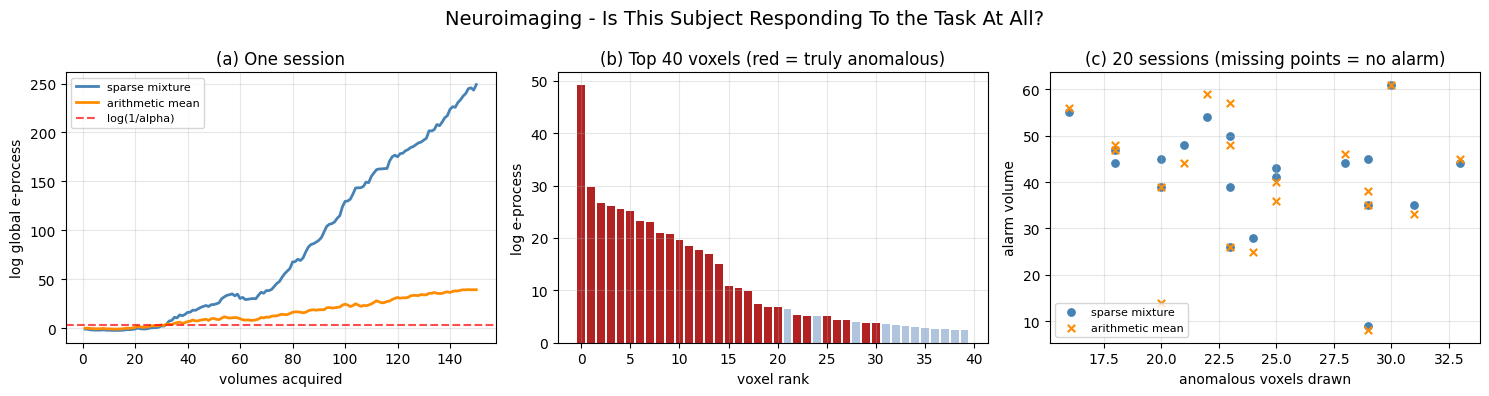

In [10]:
K = 20000
anomaly_rate, effect_mean, effect_sd = 0.00125, 0.45, 0.12
horizon, onset_max, n_worlds = 150, 1, 20


def simulate_session(seed):
    """Draw one world from the scenario, run the engine, return both merges."""
    rng = np.random.default_rng(seed)

    anomalous = rng.random(K) < anomaly_rate
    m = int(anomalous.sum())
    effect = np.zeros(K)
    effect[anomalous] = np.clip(rng.normal(effect_mean, effect_sd, m), 0.05, None)
    onset = np.ones(K, dtype=int)
    if onset_max > 1:
        onset[anomalous] = rng.integers(1, onset_max + 1, m)

    eng = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    curve_s, curve_m = [], []
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng.step(rng.standard_normal(K) + effect * (onset <= t))
        log_e = eng.log_e_processes()
        curve_s.append(sparse.merge_log(log_e).log_merged_e_value)
        curve_m.append(mean.merge(np.exp(log_e)).log_merged_e_value)
        if alarm_s is None and max(curve_s) >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max(curve_m) >= LOG_THRESHOLD:
            alarm_m = t

    return dict(engine=eng, sparse=sparse, anomalous=anomalous, effect=effect,
                curve_s=curve_s, curve_m=curve_m, alarm_s=alarm_s, alarm_m=alarm_m)


session = simulate_session(101)
truth = set(np.flatnonzero(session['anomalous']).tolist())
diagnostics = session['sparse'].diagnostics(np.exp(session['engine'].log_e_processes()))
bh = session['engine'].e_bh()
found = set(np.flatnonzero(bh.rejected).tolist())
effects_drawn = np.sort(session['effect'][session['anomalous']])[::-1]

print(f"one session: {K:,} voxels, {len(truth)} anomalous")
print(f"  largest effects drawn        : {np.round(effects_drawn[:8], 2)}")
print(f"  global alarm, sparse mixture : {session['alarm_s']}")
print(f"  global alarm, arithmetic mean: {session['alarm_m']}")
print(f"  max log e-process            : {max(session['curve_s']):.1f} (sparse) vs "
      f"{max(session['curve_m']):.1f} (mean)")
print(f"  posterior-mean anomaly count : {diagnostics.sparsity_posterior_mean * K:.1f} "
      f"voxels")
print(f"  participation ratio          : {diagnostics.participation_ratio:.1f} effective")
print(f"  e-BH shortlist               : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")

rows = [simulate_session(101 + 1000 * (w + 1)) for w in range(n_worlds)]
alarms_s = np.array([r['alarm_s'] if r['alarm_s'] else np.nan for r in rows], dtype=float)
alarms_m = np.array([r['alarm_m'] if r['alarm_m'] else np.nan for r in rows], dtype=float)
counts = np.array([int(r['anomalous'].sum()) for r in rows])

print(f"\n{n_worlds} independent sessions of the same scenario")
print(f"  anomalous voxels drawn : median {np.median(counts):.0f}, "
      f"range {counts.min()}-{counts.max()}")
print(f"  sparse mixture alarmed  : {int(np.sum(~np.isnan(alarms_s)))}/{n_worlds} sessions, "
      f"median volume {np.nanmedian(alarms_s):.0f}")
print(f"  arithmetic mean alarmed : {int(np.sum(~np.isnan(alarms_m)))}/{n_worlds} sessions, "
      f"median volume {np.nanmedian(alarms_m):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(range(1, horizon + 1), session['curve_s'], lw=2, color='steelblue',
        label='sparse mixture')
ax.plot(range(1, horizon + 1), session['curve_m'], lw=2, color='darkorange',
        label='arithmetic mean')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('volumes acquired'); ax.set_ylabel('log global e-process')
ax.set_title('(a) One session')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
log_e_final = session['engine'].log_e_processes()
order = np.argsort(log_e_final)[::-1][:40]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), log_e_final[order], color=colours)
ax.set_xlabel('voxel rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 40 voxels (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(counts, alarms_s, s=28, color='steelblue', label='sparse mixture')
ax.scatter(counts, alarms_m, s=28, color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous voxels drawn'); ax.set_ylabel('alarm volume')
ax.set_title(f'(c) {n_worlds} sessions (missing points = no alarm)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Neuroimaging - Is This Subject Responding To the Task At All?', fontsize=14)
plt.tight_layout()
plt.show()

# 9. Real World: MLOps - Feature Drift After a Deploy

**Scenario:** A production model consumes 2,000 input features, monitored as standardised
summaries per window. Somewhere in the first few hours after a deploy an upstream join
changes and some features start drifting. Nobody knows which features, how many, or
exactly when - that is what the monitor is for.

- **Streams:** 2,000 standardised feature summaries, one value per monitoring window.
- **What is unknown:** each feature is affected with probability 0.0025, drift sizes
  around 0.8 sigma (a broken join is a blunt failure, not a subtle one), and each affected
  feature starts drifting at its own randomly drawn window within the first 40.
- **Horizon:** 120 windows, about a day at 12-minute windows.

**Why sequential testing matters here:**
- Drift monitors run continuously and forever. A fixed-sample test has no meaning in that
  setting; an e-process is exactly the object whose false-alarm rate is controlled over an
  unbounded horizon.
- A page that fires on 1 feature in 2,000 every week gets muted. One global alarm plus an
  FDR-controlled shortlist is what an on-call rotation can act on.
- The change starts *after* monitoring begins, which is the realistic case: the monitor
  builds a clean baseline first and then has to notice the break.

one session: 2,000 features, 8 anomalous
  largest effects drawn        : [1.02 0.99 0.89 0.78 0.73 0.56 0.48 0.28]
  global alarm, sparse mixture : 31
  global alarm, arithmetic mean: 32
  max log e-process            : 173.4 (sparse) vs 55.1 (mean)
  posterior-mean anomaly count : 7.4 features
  participation ratio          : 4.3 effective
  e-BH shortlist               : 6 flagged, 6 true, 0 false



30 independent sessions of the same scenario
  anomalous features drawn : median 5, range 2-10
  sparse mixture alarmed  : 30/30 sessions, median window 46
  arithmetic mean alarmed : 30/30 sessions, median window 42


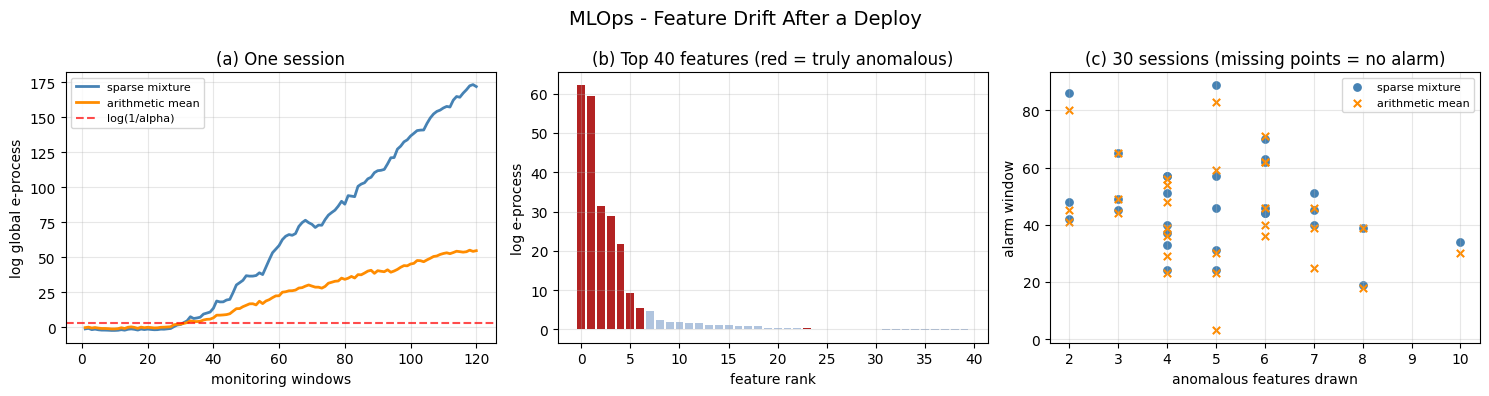

In [11]:
K = 2000
anomaly_rate, effect_mean, effect_sd = 0.0025, 0.8, 0.25
horizon, onset_max, n_worlds = 120, 40, 30


def simulate_session(seed):
    """Draw one world from the scenario, run the engine, return both merges."""
    rng = np.random.default_rng(seed)

    anomalous = rng.random(K) < anomaly_rate
    m = int(anomalous.sum())
    effect = np.zeros(K)
    effect[anomalous] = np.clip(rng.normal(effect_mean, effect_sd, m), 0.05, None)
    onset = np.ones(K, dtype=int)
    if onset_max > 1:
        onset[anomalous] = rng.integers(1, onset_max + 1, m)

    eng = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    curve_s, curve_m = [], []
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng.step(rng.standard_normal(K) + effect * (onset <= t))
        log_e = eng.log_e_processes()
        curve_s.append(sparse.merge_log(log_e).log_merged_e_value)
        curve_m.append(mean.merge(np.exp(log_e)).log_merged_e_value)
        if alarm_s is None and max(curve_s) >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max(curve_m) >= LOG_THRESHOLD:
            alarm_m = t

    return dict(engine=eng, sparse=sparse, anomalous=anomalous, effect=effect,
                curve_s=curve_s, curve_m=curve_m, alarm_s=alarm_s, alarm_m=alarm_m)


session = simulate_session(102)
truth = set(np.flatnonzero(session['anomalous']).tolist())
diagnostics = session['sparse'].diagnostics(np.exp(session['engine'].log_e_processes()))
bh = session['engine'].e_bh()
found = set(np.flatnonzero(bh.rejected).tolist())
effects_drawn = np.sort(session['effect'][session['anomalous']])[::-1]

print(f"one session: {K:,} features, {len(truth)} anomalous")
print(f"  largest effects drawn        : {np.round(effects_drawn[:8], 2)}")
print(f"  global alarm, sparse mixture : {session['alarm_s']}")
print(f"  global alarm, arithmetic mean: {session['alarm_m']}")
print(f"  max log e-process            : {max(session['curve_s']):.1f} (sparse) vs "
      f"{max(session['curve_m']):.1f} (mean)")
print(f"  posterior-mean anomaly count : {diagnostics.sparsity_posterior_mean * K:.1f} "
      f"features")
print(f"  participation ratio          : {diagnostics.participation_ratio:.1f} effective")
print(f"  e-BH shortlist               : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")

rows = [simulate_session(102 + 1000 * (w + 1)) for w in range(n_worlds)]
alarms_s = np.array([r['alarm_s'] if r['alarm_s'] else np.nan for r in rows], dtype=float)
alarms_m = np.array([r['alarm_m'] if r['alarm_m'] else np.nan for r in rows], dtype=float)
counts = np.array([int(r['anomalous'].sum()) for r in rows])

print(f"\n{n_worlds} independent sessions of the same scenario")
print(f"  anomalous features drawn : median {np.median(counts):.0f}, "
      f"range {counts.min()}-{counts.max()}")
print(f"  sparse mixture alarmed  : {int(np.sum(~np.isnan(alarms_s)))}/{n_worlds} sessions, "
      f"median window {np.nanmedian(alarms_s):.0f}")
print(f"  arithmetic mean alarmed : {int(np.sum(~np.isnan(alarms_m)))}/{n_worlds} sessions, "
      f"median window {np.nanmedian(alarms_m):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(range(1, horizon + 1), session['curve_s'], lw=2, color='steelblue',
        label='sparse mixture')
ax.plot(range(1, horizon + 1), session['curve_m'], lw=2, color='darkorange',
        label='arithmetic mean')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('monitoring windows'); ax.set_ylabel('log global e-process')
ax.set_title('(a) One session')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
log_e_final = session['engine'].log_e_processes()
order = np.argsort(log_e_final)[::-1][:40]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), log_e_final[order], color=colours)
ax.set_xlabel('feature rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 40 features (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(counts, alarms_s, s=28, color='steelblue', label='sparse mixture')
ax.scatter(counts, alarms_m, s=28, color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous features drawn'); ax.set_ylabel('alarm window')
ax.set_title(f'(c) {n_worlds} sessions (missing points = no alarm)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('MLOps - Feature Drift After a Deploy', fontsize=14)
plt.tight_layout()
plt.show()

# 10. Real World: Supply Chain - SKU Demand Anomalies

**Scenario:** A retailer forecasts demand for 1,500 SKUs and monitors standardised
forecast residuals. Some SKUs begin to run hot - a competitor delisted a product, a
promotion leaked early, a regional shortage started. Planners need to know the forecast
as a whole has broken before safety stock is eaten.

- **Streams:** 1,500 SKUs, one standardised residual per replenishment cycle.
- **What is unknown:** each SKU runs hot with probability 0.008 - a broader, less sparse
  disturbance than the other scenarios, because demand shocks propagate across related
  products - with residual shifts around 0.5 sigma.
- **Horizon:** 100 cycles.

**Why sequential testing matters here:**
- Stockouts compound: every cycle of under-forecasting digs the hole deeper, so the value
  of detection decays fast with delay.
- Several moderately hot SKUs is the "many streams, each individually informative" regime,
  which is where multiplicative merging has the most to offer.
- The participation ratio tells the planner roughly how many SKUs are involved before any
  per-SKU test is run, which sets the size of the expediting response.

one session: 1,500 SKUs, 14 anomalous
  largest effects drawn        : [0.83 0.67 0.63 0.59 0.58 0.46 0.46 0.41]
  global alarm, sparse mixture : 36
  global alarm, arithmetic mean: 32
  max log e-process            : 66.0 (sparse) vs 33.0 (mean)
  posterior-mean anomaly count : 6.9 SKUs
  participation ratio          : 3.3 effective
  e-BH shortlist               : 4 flagged, 4 true, 0 false



30 independent sessions of the same scenario
  anomalous SKUs drawn : median 13, range 6-18
  sparse mixture alarmed  : 30/30 sessions, median cycle 29
  arithmetic mean alarmed : 30/30 sessions, median cycle 28


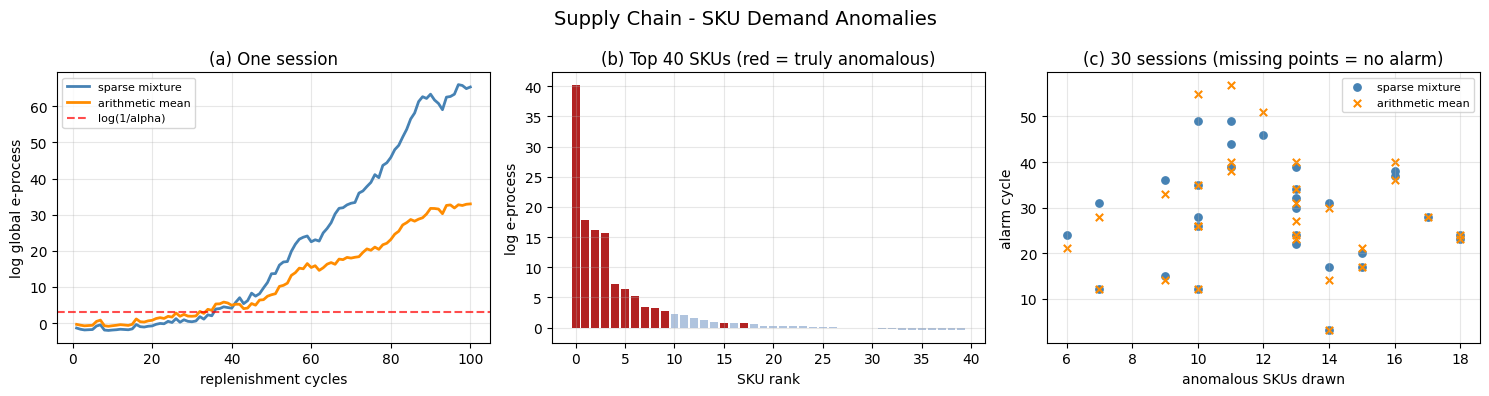

In [12]:
K = 1500
anomaly_rate, effect_mean, effect_sd = 0.008, 0.5, 0.15
horizon, onset_max, n_worlds = 100, 1, 30


def simulate_session(seed):
    """Draw one world from the scenario, run the engine, return both merges."""
    rng = np.random.default_rng(seed)

    anomalous = rng.random(K) < anomaly_rate
    m = int(anomalous.sum())
    effect = np.zeros(K)
    effect[anomalous] = np.clip(rng.normal(effect_mean, effect_sd, m), 0.05, None)
    onset = np.ones(K, dtype=int)
    if onset_max > 1:
        onset[anomalous] = rng.integers(1, onset_max + 1, m)

    eng = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    curve_s, curve_m = [], []
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng.step(rng.standard_normal(K) + effect * (onset <= t))
        log_e = eng.log_e_processes()
        curve_s.append(sparse.merge_log(log_e).log_merged_e_value)
        curve_m.append(mean.merge(np.exp(log_e)).log_merged_e_value)
        if alarm_s is None and max(curve_s) >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max(curve_m) >= LOG_THRESHOLD:
            alarm_m = t

    return dict(engine=eng, sparse=sparse, anomalous=anomalous, effect=effect,
                curve_s=curve_s, curve_m=curve_m, alarm_s=alarm_s, alarm_m=alarm_m)


session = simulate_session(103)
truth = set(np.flatnonzero(session['anomalous']).tolist())
diagnostics = session['sparse'].diagnostics(np.exp(session['engine'].log_e_processes()))
bh = session['engine'].e_bh()
found = set(np.flatnonzero(bh.rejected).tolist())
effects_drawn = np.sort(session['effect'][session['anomalous']])[::-1]

print(f"one session: {K:,} SKUs, {len(truth)} anomalous")
print(f"  largest effects drawn        : {np.round(effects_drawn[:8], 2)}")
print(f"  global alarm, sparse mixture : {session['alarm_s']}")
print(f"  global alarm, arithmetic mean: {session['alarm_m']}")
print(f"  max log e-process            : {max(session['curve_s']):.1f} (sparse) vs "
      f"{max(session['curve_m']):.1f} (mean)")
print(f"  posterior-mean anomaly count : {diagnostics.sparsity_posterior_mean * K:.1f} "
      f"SKUs")
print(f"  participation ratio          : {diagnostics.participation_ratio:.1f} effective")
print(f"  e-BH shortlist               : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")

rows = [simulate_session(103 + 1000 * (w + 1)) for w in range(n_worlds)]
alarms_s = np.array([r['alarm_s'] if r['alarm_s'] else np.nan for r in rows], dtype=float)
alarms_m = np.array([r['alarm_m'] if r['alarm_m'] else np.nan for r in rows], dtype=float)
counts = np.array([int(r['anomalous'].sum()) for r in rows])

print(f"\n{n_worlds} independent sessions of the same scenario")
print(f"  anomalous SKUs drawn : median {np.median(counts):.0f}, "
      f"range {counts.min()}-{counts.max()}")
print(f"  sparse mixture alarmed  : {int(np.sum(~np.isnan(alarms_s)))}/{n_worlds} sessions, "
      f"median cycle {np.nanmedian(alarms_s):.0f}")
print(f"  arithmetic mean alarmed : {int(np.sum(~np.isnan(alarms_m)))}/{n_worlds} sessions, "
      f"median cycle {np.nanmedian(alarms_m):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(range(1, horizon + 1), session['curve_s'], lw=2, color='steelblue',
        label='sparse mixture')
ax.plot(range(1, horizon + 1), session['curve_m'], lw=2, color='darkorange',
        label='arithmetic mean')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('replenishment cycles'); ax.set_ylabel('log global e-process')
ax.set_title('(a) One session')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
log_e_final = session['engine'].log_e_processes()
order = np.argsort(log_e_final)[::-1][:40]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), log_e_final[order], color=colours)
ax.set_xlabel('SKU rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 40 SKUs (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(counts, alarms_s, s=28, color='steelblue', label='sparse mixture')
ax.scatter(counts, alarms_m, s=28, color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous SKUs drawn'); ax.set_ylabel('alarm cycle')
ax.set_title(f'(c) {n_worlds} sessions (missing points = no alarm)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Supply Chain - SKU Demand Anomalies', fontsize=14)
plt.tight_layout()
plt.show()

# 11. Real World: LLM Operations - Prompt-Cluster Quality Regression

**Scenario:** A deployed assistant serves traffic clustered into 5,000 prompt families,
each scored per batch. After a model or retrieval change some families regress - a
tool-call format broke, a retrieval index went stale for one language - while aggregate
quality barely moves and every dashboard stays green.

- **Streams:** 5,000 prompt clusters, one standardised quality score per batch.
- **What is unknown:** each cluster regresses with probability 0.0012, by around 0.5
  sigma. On average that is about six clusters out of five thousand, but the realised
  number and sizes vary from release to release.
- **Horizon:** 150 batches.

**Why sequential testing matters here:**
- Aggregate quality metrics hide exactly this failure mode: six families out of five
  thousand cannot move the average, but they can be the six families that matter to a
  large customer.
- Evaluation traffic arrives continuously and the team wants to know "has anything
  regressed" between releases, not at a scheduled evaluation run.
- The top-streams shortlist is the triage queue: it names the prompt families to inspect,
  ranked, without any further testing.

one session: 5,000 prompt clusters, 6 anomalous
  largest effects drawn        : [0.57 0.55 0.54 0.53 0.46 0.27]
  global alarm, sparse mixture : 55
  global alarm, arithmetic mean: 55
  max log e-process            : 57.0 (sparse) vs 19.9 (mean)
  posterior-mean anomaly count : 5.5 prompt clusters
  participation ratio          : 4.1 effective
  e-BH shortlist               : 5 flagged, 5 true, 0 false



30 independent sessions of the same scenario
  anomalous prompt clusters drawn : median 5, range 1-10
  sparse mixture alarmed  : 30/30 sessions, median batch 57
  arithmetic mean alarmed : 30/30 sessions, median batch 53


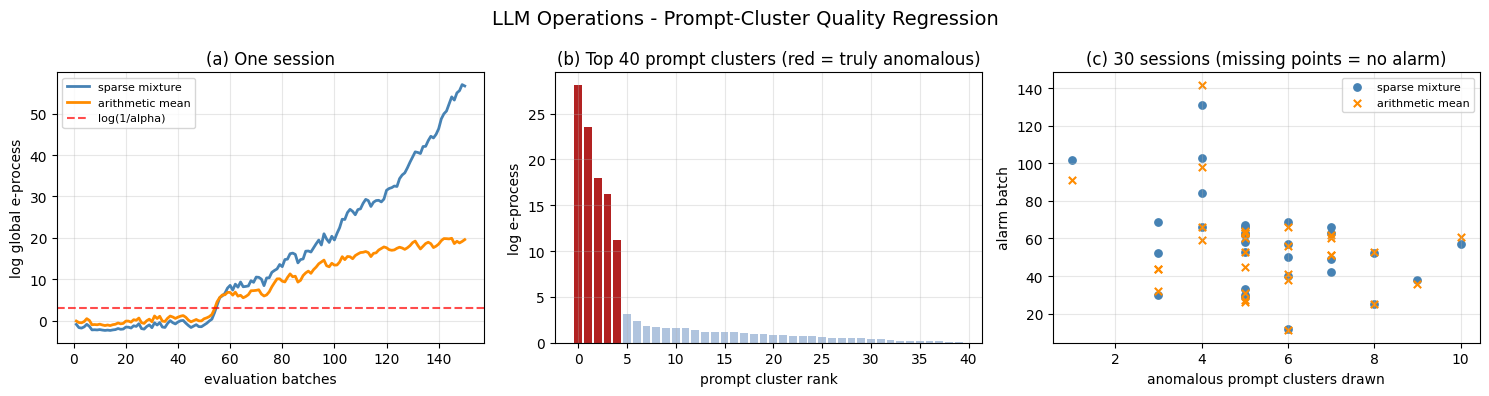

In [13]:
K = 5000
anomaly_rate, effect_mean, effect_sd = 0.0012, 0.5, 0.15
horizon, onset_max, n_worlds = 150, 1, 30


def simulate_session(seed):
    """Draw one world from the scenario, run the engine, return both merges."""
    rng = np.random.default_rng(seed)

    anomalous = rng.random(K) < anomaly_rate
    m = int(anomalous.sum())
    effect = np.zeros(K)
    effect[anomalous] = np.clip(rng.normal(effect_mean, effect_sd, m), 0.05, None)
    onset = np.ones(K, dtype=int)
    if onset_max > 1:
        onset[anomalous] = rng.integers(1, onset_max + 1, m)

    eng = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    curve_s, curve_m = [], []
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng.step(rng.standard_normal(K) + effect * (onset <= t))
        log_e = eng.log_e_processes()
        curve_s.append(sparse.merge_log(log_e).log_merged_e_value)
        curve_m.append(mean.merge(np.exp(log_e)).log_merged_e_value)
        if alarm_s is None and max(curve_s) >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max(curve_m) >= LOG_THRESHOLD:
            alarm_m = t

    return dict(engine=eng, sparse=sparse, anomalous=anomalous, effect=effect,
                curve_s=curve_s, curve_m=curve_m, alarm_s=alarm_s, alarm_m=alarm_m)


session = simulate_session(104)
truth = set(np.flatnonzero(session['anomalous']).tolist())
diagnostics = session['sparse'].diagnostics(np.exp(session['engine'].log_e_processes()))
bh = session['engine'].e_bh()
found = set(np.flatnonzero(bh.rejected).tolist())
effects_drawn = np.sort(session['effect'][session['anomalous']])[::-1]

print(f"one session: {K:,} prompt clusters, {len(truth)} anomalous")
print(f"  largest effects drawn        : {np.round(effects_drawn[:8], 2)}")
print(f"  global alarm, sparse mixture : {session['alarm_s']}")
print(f"  global alarm, arithmetic mean: {session['alarm_m']}")
print(f"  max log e-process            : {max(session['curve_s']):.1f} (sparse) vs "
      f"{max(session['curve_m']):.1f} (mean)")
print(f"  posterior-mean anomaly count : {diagnostics.sparsity_posterior_mean * K:.1f} "
      f"prompt clusters")
print(f"  participation ratio          : {diagnostics.participation_ratio:.1f} effective")
print(f"  e-BH shortlist               : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")

rows = [simulate_session(104 + 1000 * (w + 1)) for w in range(n_worlds)]
alarms_s = np.array([r['alarm_s'] if r['alarm_s'] else np.nan for r in rows], dtype=float)
alarms_m = np.array([r['alarm_m'] if r['alarm_m'] else np.nan for r in rows], dtype=float)
counts = np.array([int(r['anomalous'].sum()) for r in rows])

print(f"\n{n_worlds} independent sessions of the same scenario")
print(f"  anomalous prompt clusters drawn : median {np.median(counts):.0f}, "
      f"range {counts.min()}-{counts.max()}")
print(f"  sparse mixture alarmed  : {int(np.sum(~np.isnan(alarms_s)))}/{n_worlds} sessions, "
      f"median batch {np.nanmedian(alarms_s):.0f}")
print(f"  arithmetic mean alarmed : {int(np.sum(~np.isnan(alarms_m)))}/{n_worlds} sessions, "
      f"median batch {np.nanmedian(alarms_m):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(range(1, horizon + 1), session['curve_s'], lw=2, color='steelblue',
        label='sparse mixture')
ax.plot(range(1, horizon + 1), session['curve_m'], lw=2, color='darkorange',
        label='arithmetic mean')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('evaluation batches'); ax.set_ylabel('log global e-process')
ax.set_title('(a) One session')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
log_e_final = session['engine'].log_e_processes()
order = np.argsort(log_e_final)[::-1][:40]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), log_e_final[order], color=colours)
ax.set_xlabel('prompt cluster rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 40 prompt clusters (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(counts, alarms_s, s=28, color='steelblue', label='sparse mixture')
ax.scatter(counts, alarms_m, s=28, color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous prompt clusters drawn'); ax.set_ylabel('alarm batch')
ax.set_title(f'(c) {n_worlds} sessions (missing points = no alarm)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('LLM Operations - Prompt-Cluster Quality Regression', fontsize=14)
plt.tight_layout()
plt.show()

# 12. Real World: Clinical Safety Surveillance Across Hospital Units

**Scenario:** A hospital network monitors standardised excess adverse-event rates across
3,000 units (ward x procedure combinations). Some units deteriorate. A safety board wants
a single defensible signal that the network as a whole has a problem, plus the list of
units to investigate.

- **Streams:** 3,000 unit-level standardised excess-event rates, one per reporting period.
- **What is unknown:** each unit deteriorates with probability 0.0015, by around 0.6 sigma
  with substantial spread - deterioration is heterogeneous, and some units drift so little
  that no method can find them within the horizon.
- **Horizon:** 100 reporting periods.

**Why sequential testing matters here:**
- Safety monitoring is continuous and open-ended by law. The guarantee has to hold at
  every look, including the unscheduled ones triggered by an incident report.
- The alarm must survive external scrutiny. "The running maximum of an e-process reached
  1/alpha" is a statement about the whole monitoring history; "p < 0.05 at the eleventh
  look" is not.
- A handful of units in 3,000 is sparse enough that a network-wide average is useless and
  unit-by-unit testing is badly underpowered.

one session: 3,000 units, 2 anomalous
  largest effects drawn        : [0.61 0.48]
  global alarm, sparse mixture : 32
  global alarm, arithmetic mean: 31
  max log e-process            : 6.8 (sparse) vs 6.9 (mean)
  posterior-mean anomaly count : 2.8 units
  participation ratio          : 2.0 effective
  e-BH shortlist               : 0 flagged, 0 true, 0 false



30 independent sessions of the same scenario
  anomalous units drawn : median 5, range 2-9
  sparse mixture alarmed  : 29/30 sessions, median period 35
  arithmetic mean alarmed : 29/30 sessions, median period 32


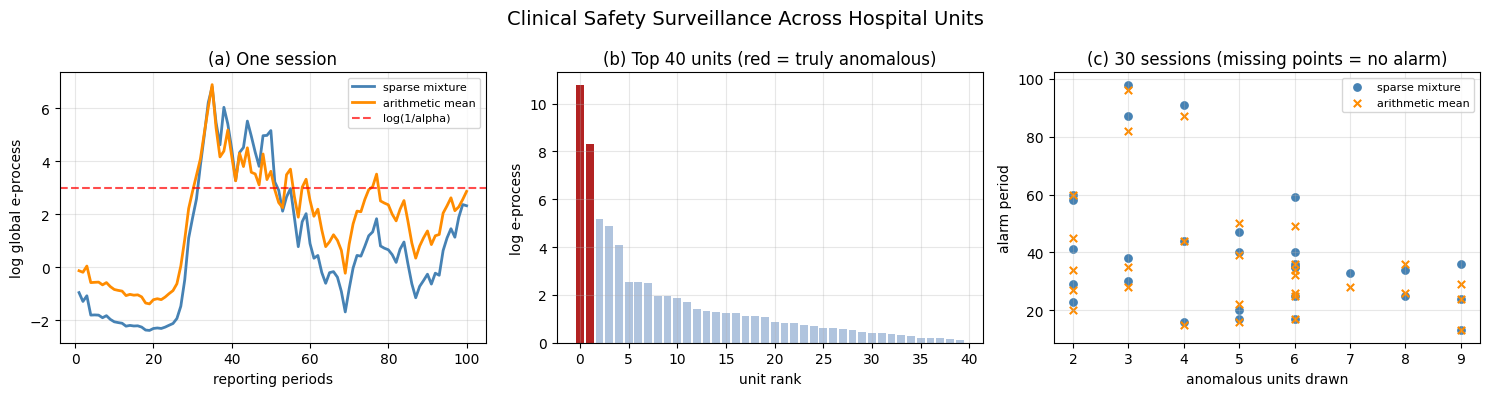

In [14]:
K = 3000
anomaly_rate, effect_mean, effect_sd = 0.0015, 0.6, 0.2
horizon, onset_max, n_worlds = 100, 1, 30


def simulate_session(seed):
    """Draw one world from the scenario, run the engine, return both merges."""
    rng = np.random.default_rng(seed)

    anomalous = rng.random(K) < anomaly_rate
    m = int(anomalous.sum())
    effect = np.zeros(K)
    effect[anomalous] = np.clip(rng.normal(effect_mean, effect_sd, m), 0.05, None)
    onset = np.ones(K, dtype=int)
    if onset_max > 1:
        onset[anomalous] = rng.integers(1, onset_max + 1, m)

    eng = ParallelSequentialTest(
        config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater",
                                  combiner="all_in"),
        null_values=0.0,
        variance=1.0,
    )
    sparse, mean = SparseMixtureMerger(K), ArithmeticMeanMerger(K)

    curve_s, curve_m = [], []
    alarm_s = alarm_m = None
    for t in range(1, horizon + 1):
        eng.step(rng.standard_normal(K) + effect * (onset <= t))
        log_e = eng.log_e_processes()
        curve_s.append(sparse.merge_log(log_e).log_merged_e_value)
        curve_m.append(mean.merge(np.exp(log_e)).log_merged_e_value)
        if alarm_s is None and max(curve_s) >= LOG_THRESHOLD:
            alarm_s = t
        if alarm_m is None and max(curve_m) >= LOG_THRESHOLD:
            alarm_m = t

    return dict(engine=eng, sparse=sparse, anomalous=anomalous, effect=effect,
                curve_s=curve_s, curve_m=curve_m, alarm_s=alarm_s, alarm_m=alarm_m)


session = simulate_session(105)
truth = set(np.flatnonzero(session['anomalous']).tolist())
diagnostics = session['sparse'].diagnostics(np.exp(session['engine'].log_e_processes()))
bh = session['engine'].e_bh()
found = set(np.flatnonzero(bh.rejected).tolist())
effects_drawn = np.sort(session['effect'][session['anomalous']])[::-1]

print(f"one session: {K:,} units, {len(truth)} anomalous")
print(f"  largest effects drawn        : {np.round(effects_drawn[:8], 2)}")
print(f"  global alarm, sparse mixture : {session['alarm_s']}")
print(f"  global alarm, arithmetic mean: {session['alarm_m']}")
print(f"  max log e-process            : {max(session['curve_s']):.1f} (sparse) vs "
      f"{max(session['curve_m']):.1f} (mean)")
print(f"  posterior-mean anomaly count : {diagnostics.sparsity_posterior_mean * K:.1f} "
      f"units")
print(f"  participation ratio          : {diagnostics.participation_ratio:.1f} effective")
print(f"  e-BH shortlist               : {bh.n_rejected} flagged, "
      f"{len(found & truth)} true, {len(found - truth)} false")

rows = [simulate_session(105 + 1000 * (w + 1)) for w in range(n_worlds)]
alarms_s = np.array([r['alarm_s'] if r['alarm_s'] else np.nan for r in rows], dtype=float)
alarms_m = np.array([r['alarm_m'] if r['alarm_m'] else np.nan for r in rows], dtype=float)
counts = np.array([int(r['anomalous'].sum()) for r in rows])

print(f"\n{n_worlds} independent sessions of the same scenario")
print(f"  anomalous units drawn : median {np.median(counts):.0f}, "
      f"range {counts.min()}-{counts.max()}")
print(f"  sparse mixture alarmed  : {int(np.sum(~np.isnan(alarms_s)))}/{n_worlds} sessions, "
      f"median period {np.nanmedian(alarms_s):.0f}")
print(f"  arithmetic mean alarmed : {int(np.sum(~np.isnan(alarms_m)))}/{n_worlds} sessions, "
      f"median period {np.nanmedian(alarms_m):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(range(1, horizon + 1), session['curve_s'], lw=2, color='steelblue',
        label='sparse mixture')
ax.plot(range(1, horizon + 1), session['curve_m'], lw=2, color='darkorange',
        label='arithmetic mean')
ax.axhline(LOG_THRESHOLD, color='red', ls='--', alpha=0.7, label='log(1/alpha)')
ax.set_xlabel('reporting periods'); ax.set_ylabel('log global e-process')
ax.set_title('(a) One session')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
log_e_final = session['engine'].log_e_processes()
order = np.argsort(log_e_final)[::-1][:40]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), log_e_final[order], color=colours)
ax.set_xlabel('unit rank'); ax.set_ylabel('log e-process')
ax.set_title('(b) Top 40 units (red = truly anomalous)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(counts, alarms_s, s=28, color='steelblue', label='sparse mixture')
ax.scatter(counts, alarms_m, s=28, color='darkorange', marker='x', label='arithmetic mean')
ax.set_xlabel('anomalous units drawn'); ax.set_ylabel('alarm period')
ax.set_title(f'(c) {n_worlds} sessions (missing points = no alarm)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Clinical Safety Surveillance Across Hospital Units', fontsize=14)
plt.tight_layout()
plt.show()

# 13. How It Works: The Sparse Mixture and Its Gambling System

Each stream $k$ runs its own test supermartingale $e_k$ against its own null. The merge
over a single sparsity level $\varepsilon$ is a lambda-product,

$$F_\varepsilon(e) \;=\; \prod_{k=1}^{K} \bigl(1 - \varepsilon + \varepsilon\, e_k\bigr),$$

which is the adaptive sparse-anomaly test martingale of Perez-Ortiz, Castro & Stoepker
(2025), Eq. (6). Since the true fraction is unknown, mix over their grid (9),
$\varepsilon_j = K^{-\beta_j}$ with $\beta_j \in (1/2, 1]$:

$$F(e) \;=\; \sum_j \pi_j \prod_{k=1}^{K} \bigl(1 - \varepsilon_j + \varepsilon_j e_k\bigr).$$

**Why this compounds.** Take $m$ anomalous streams, each with e-value $e$. For
$\varepsilon \approx 1/K$, each contributes $\log(1 + e/K)$, so the total is about
$m \log(e/K)$ once $e \gg K$: the evidence is **multiplicative across streams**. The
arithmetic mean gives $\log(m e / K)$, which grows only logarithmically in $m$. That is
the whole difference, and it also explains the cost: each of the $K - m$ null streams
contributes $\log(1 - \varepsilon + \varepsilon e_k) \approx \varepsilon(e_k - 1)$, so a
large $\varepsilon$ is charged $\varepsilon K$ times the average shortfall of the null
e-values. The mixture buys its way out by putting weight on small $\varepsilon$.

It also explains something visible in every replication above: the sparse mixture's
advantage shows up first in **evidence**, not in alarm time. Crossing $\log(1/\alpha)$
needs only 3 nats, which the mean often reaches at nearly the same moment; the gap in
accumulated evidence afterwards is what makes the alarm defensible and the localisation
sharp.

**It is a gambling system.** By Vovk & Wang (2024), Eq. (4), every martingale merging
function is a sequential betting strategy over the index $k$. For the sparse mixture the
gambling system is the **posterior-mean sparsity**

$$s_k(e_1,\dots,e_k) \;=\; \sum_j w_j \varepsilon_j, \qquad
w_j \;\propto\; \pi_j \prod_{i \leq k} (1 - \varepsilon_j + \varepsilon_j e_i),$$

and $\prod_k \bigl(1 + s_k (e_{k+1} - 1)\bigr)$ reproduces $F(e)$ exactly - the library
tests this identity. `gambling_system()` returns those bets, and `diagnostics()` returns
the posterior $w$, plotted in section 1.

**The detection boundary.** For $\varepsilon = K^{-\beta}$ and per-step signal
$\delta = \sqrt{2 \ln K / T^*}$, detection is impossible before $t^* = T^* \rho(\beta)$ with

$$\rho(\beta) = \begin{cases}\beta - \tfrac12, & \tfrac12 < \beta \leq \tfrac34,\\
(1 - \sqrt{1-\beta})^2, & \tfrac34 \leq \beta \leq 1,\end{cases}$$

the Donoho-Jin (2004, Section 1.1) boundary, exposed as `detection_boundary(beta)`.

**The contract you must honour.** The product structure requires the $K$ streams to be
**independent** (Wang, Dandapanthula & Ramdas 2025). Correlated voxels, features sharing
an upstream join, SKUs in the same category - all break it. Every simulation here draws
independent streams, which is the favourable case for the sparse mixture; with dependence
present or unknown, use `ArithmeticMeanMerger`, which is valid under arbitrary dependence,
and accept the loss in evidence shown above. There is no free lunch: the sparse mixture
buys its compounding with an assumption.

**One more contract.** `merge` and `merge_log` take the *current values* of the per-stream
processes and return a global e-process value. They already account for time through the
per-stream martingales; feeding the merged output into another temporal accumulator would
double-count and destroy validity.